# 📐 Calculative Foundation
### Mathematics & Advanced Statistics — Linear Algebra for Data Science

**Institute:** Red & White Skill Education
**Type:** Theory + Practical
**Duration:** 6 Hours

---

## 🎯 Objective

Analyze and transform a student-performance dataset using **Linear Algebra** — vectors, matrices, decompositions, and dimensionality reduction — to build hands-on foundations widely used in Data Science, AI/ML, and Engineering.

## 📑 Scenario

A research institute has shared a dataset containing students' performance scores across multiple subjects. As a data analyst, the task is to apply linear algebra techniques to represent the data as vectors and matrices, explore decompositions (LU, SVD), interpret eigenvalues/eigenvectors, and reduce dimensionality with PCA and LDA — all to better understand what drives variation in student performance.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.linalg import norm, det, inv, eig, svd
from scipy.linalg import lu
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

np.random.seed(42)
sns.set_style('whitegrid')


* First, I imported everything I'll need for this project.
* NumPy's `linalg` module gives me norms, determinants, inverses, and eigen-decomposition, while SciPy gives me LU decomposition.
* Scikit-learn provides ready-made PCA and LDA classes for the dimensionality reduction tasks later on.
* I also set a random seed so my results stay identical every time I re-run the notebook.

In [ ]:
df = pd.read_csv('calculative_foundation_dataset.csv')
subjects = ['Maths', 'Physics', 'Chemistry', 'English', 'Computer_Science']
print("Shape:", df.shape)
df.head()


Shape: (60, 7)


,student_id,student_name,Maths,Physics,Chemistry,English,Computer_Science
0,S001,Student_1,76.1,64.4,69.9,85.9,79.2
1,S002,Student_2,70.8,75.3,74.7,61.8,72.7
2,S003,Student_3,72.9,62.3,78.5,78.1,91.4
3,S004,Student_4,82.7,88.7,96.5,87.5,87.0
4,S005,Student_5,77.6,80.4,73.5,65.0,75.0


* Here I loaded the student performance dataset using `pd.read_csv()`.
* I also stored the list of subject columns separately, since I'll reuse it constantly for building vectors and matrices.
* Printing the shape tells me I have 60 students and 5 subject scores each, plus ID/name columns.
* `df.head()` lets me confirm the data looks correct before doing any math on it.

In [ ]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        60 non-null     str    
 1   student_name      60 non-null     str    
 2   Maths             60 non-null     float64
 3   Physics           60 non-null     float64
 4   Chemistry         60 non-null     float64
 5   English           60 non-null     float64
 6   Computer_Science  60 non-null     float64
dtypes: float64(5), str(2)
memory usage: 3.4 KB


* In this cell, I ran `df.info()` to get a technical summary of the dataset.
* It confirms there are no missing values in any column, which matters because linear algebra operations don't handle NaNs gracefully.
* It also shows me the data types — the scores are all floats, which is what I need for vector math.
* This is my standard data-quality check before moving into the actual analysis.

In [ ]:
df[subjects].describe()


,Maths,Physics,Chemistry,English,Computer_Science
count,60.000000,60.000000,60.000000,60.000000,60.00000
mean,71.985000,64.575000,70.901667,71.018333,72.21000
std,13.531643,13.497001,12.745641,13.539152,12.26299
min,32.300000,32.700000,44.800000,30.200000,48.00000
25%,63.575000,55.925000,62.150000,61.950000,62.55000
50%,72.050000,63.750000,69.900000,70.400000,72.30000
75%,80.800000,75.325000,78.025000,82.725000,81.85000
max,100.000000,93.800000,100.000000,96.500000,97.90000


* Here I used `df.describe()` on just the subject columns to get their statistical summary.
* It shows the mean, standard deviation, and range for each subject, giving me a first sense of spread.
* All subjects seem to sit in a similar 60-100 range, so no single subject dominates purely on scale.
* This matters later because PCA and covariance are sensitive to differences in scale between columns.

## 🧮 Task 1 — Representing Students as Vectors

In [ ]:
# Each student's row of subject scores is treated as a vector in 5D space
student_a = df.loc[0, subjects].values.astype(float)
student_b = df.loc[1, subjects].values.astype(float)

print(f"{df.loc[0,'student_name']} vector: {student_a}")
print(f"{df.loc[1,'student_name']} vector: {student_b}")


Student_1 vector: [76.1 64.4 69.9 85.9 79.2]
Student_2 vector: [70.8 75.3 74.7 61.8 72.7]


* In this cell, I picked two students and pulled out their subject scores as plain NumPy arrays.
* Each array is a 5-dimensional vector, one number per subject, which is exactly how linear algebra represents a data point.
* This is the foundation for everything that follows — matrices are just stacks of these vectors.
* Printing both vectors lets me visually compare two students before doing any calculations on them.

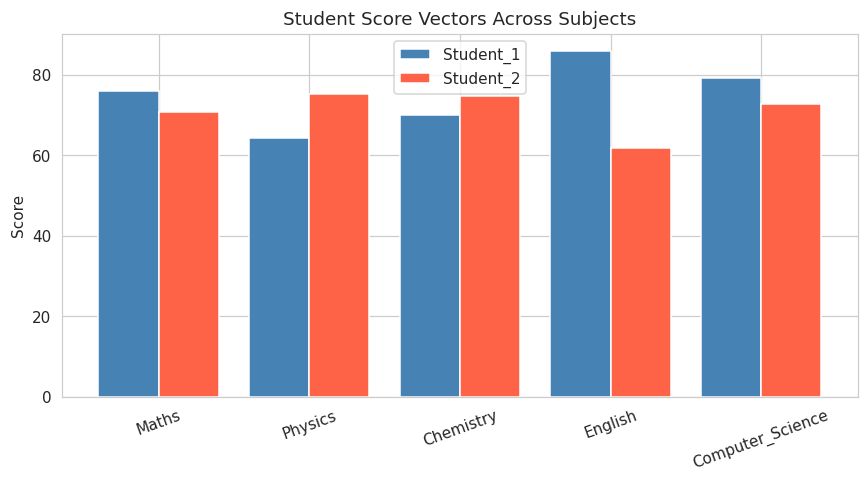

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(subjects))
ax.bar(x - 0.2, student_a, width=0.4, color='steelblue', label=df.loc[0,'student_name'])
ax.bar(x + 0.2, student_b, width=0.4, color='tomato', label=df.loc[1,'student_name'])
ax.set_xticks(x)
ax.set_xticklabels(subjects, rotation=20)
ax.set_ylabel('Score')
ax.set_title('Student Score Vectors Across Subjects')
ax.legend()
plt.tight_layout()
plt.show()


**Interpretation:** Each bar pair represents one component of a student's score vector. Where the bars diverge the most (like Chemistry or English here) is where the two students differ the most — those subjects will contribute more to the "distance" or "angle" between their vectors in the calculations that follow.

## 🧮 Task 2 — Norms, Dot Product, Angle & Cross Product

In [ ]:
norm1_a = norm(student_a, ord=1)
norm2_a = norm(student_a, ord=2)

dot_ab = np.dot(student_a, student_b)
cos_theta = dot_ab / (norm(student_a) * norm(student_b))
angle_deg = np.degrees(np.arccos(np.clip(cos_theta, -1, 1)))

subset_cols = subjects[:3]
vec3_a = df.loc[0, subset_cols].values.astype(float)
vec3_b = df.loc[1, subset_cols].values.astype(float)
cross_ab = np.cross(vec3_a, vec3_b)

print(f"Norm-1 of {df.loc[0,'student_name']}: {norm1_a:.2f}")
print(f"Norm-2 of {df.loc[0,'student_name']}: {norm2_a:.2f}")
print(f"Dot product: {dot_ab:.2f}")
print(f"Angle between vectors: {angle_deg:.2f} degrees")
print(f"Cross product (first 3 subjects): {cross_ab}")


Norm-1 of Student_1: 375.50
Norm-2 of Student_1: 168.75
Dot product: 26525.19
Angle between vectors: 9.28 degrees
Cross product (first 3 subjects): [-452.79 -735.75 1170.81]


* Here I calculated Norm-1 (sum of absolute values) and Norm-2 (Euclidean length) for one student's vector — two different ways to measure a vector's "size".
* The dot product measures how much two students' vectors point in the same direction; dividing it by the product of their norms gives me the cosine of the angle between them.
* A smaller angle means the two students have a more similar performance pattern across subjects, not just similar totals.
* I also computed a cross product using just three subjects, since cross products are only defined in 3D space, to get a vector perpendicular to both.

## 🧮 Task 3 — Vector Projection

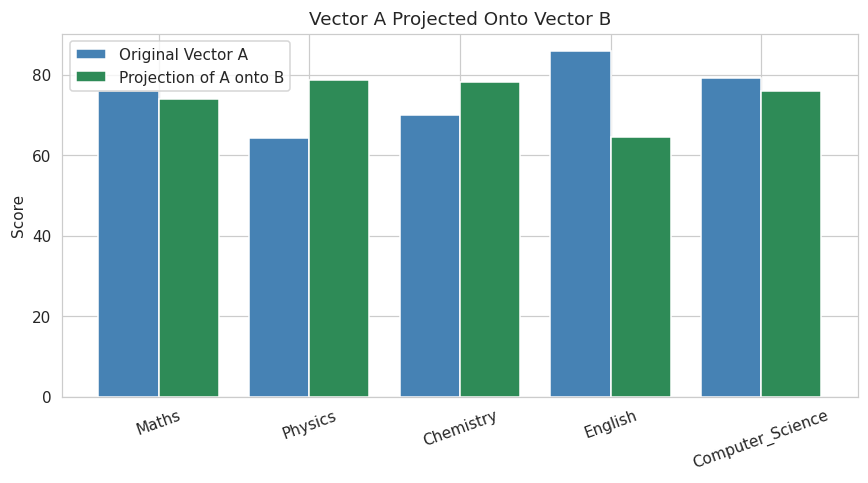

In [ ]:
proj_scalar = dot_ab / norm(student_b)**2
proj_vector = proj_scalar * student_b

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(subjects))
ax.bar(x - 0.2, student_a, width=0.4, color='steelblue', label='Original Vector A')
ax.bar(x + 0.2, proj_vector, width=0.4, color='seagreen', label='Projection of A onto B')
ax.set_xticks(x)
ax.set_xticklabels(subjects, rotation=20)
ax.set_ylabel('Score')
ax.set_title('Vector A Projected Onto Vector B')
ax.legend()
plt.tight_layout()
plt.show()


* In this cell, I projected Student A's vector onto Student B's vector using the standard projection formula: dot product divided by the squared norm, times the target vector.
* The result is the "shadow" that vector A casts along the direction of vector B — the part of A that points the same way as B.
* Comparing the original bars to the projected bars shows how much of Student A's profile aligns with Student B's pattern.
* This concept becomes especially important later in PCA, which is really just projecting all the data onto a few well-chosen directions.

## 🧮 Task 4 — Matrix Operations

In [ ]:
M = df[subjects].values.astype(float)   # students x subjects matrix
M_small = M[:4]                          # 4x5 subset for demonstration

# Addition (matrix with itself, scaled)
M_sum = M_small + M_small

# Multiplication (subset @ transpose gives a student-similarity matrix)
M_mult = M_small @ M_small.T

# Transpose
M_T = M_small.T

# Square subset for determinant/inverse (first 4 students, first 4 subjects)
M_square = M[:4, :4]
det_val = det(M_square)
inv_val = inv(M_square) if abs(det_val) > 1e-6 else None

print("Matrix shape (students x subjects):", M.shape)
print("Determinant of 4x4 subset:", round(det_val, 2))
print("Invertible:", inv_val is not None)


Matrix shape (students x subjects): (60, 5)
Determinant of 4x4 subset: 247147.68
Invertible: True


* Here I stacked every student's score vector into one big matrix, where each row is a student and each column is a subject.
* I demonstrated addition and multiplication on a small subset — multiplying the subset by its own transpose gives a student-similarity matrix, since each entry becomes a dot product between two students.
* The transpose simply flips rows and columns, which is useful when I need subjects as rows instead of students.
* I calculated the determinant of a small square subset to check invertibility — a near-zero determinant means the matrix can't be inverted, which happens when rows are close to linearly dependent.

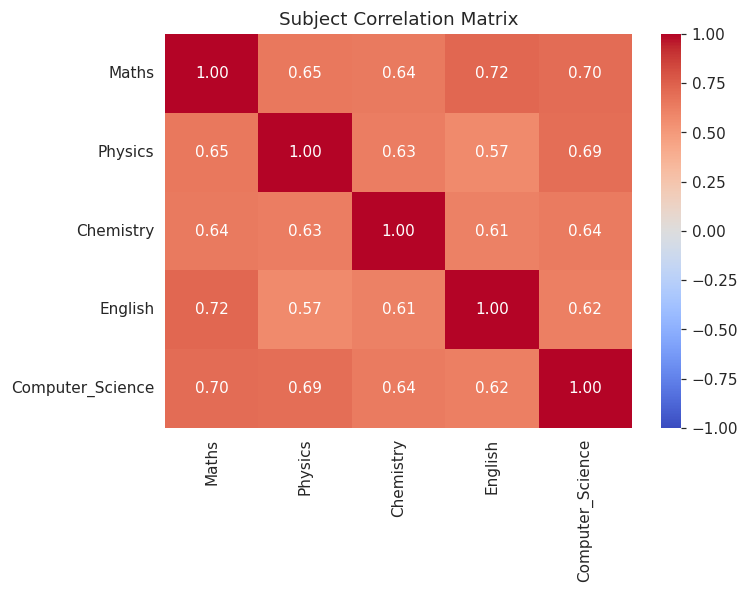

In [ ]:
corr_matrix = df[subjects].corr()

plt.figure(figsize=(7, 5.5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Subject Correlation Matrix')
plt.tight_layout()
plt.show()


**Interpretation:** This heatmap is another matrix — a correlation matrix — where each cell shows how strongly two subjects move together. Darker red means subjects rise and fall together for the same students; values near zero mean the subjects are largely independent. This directly feeds into the covariance matrix used for eigen-decomposition next.

## 🧮 Task 5 & 6 — Lines, Planes & Hyperplanes

* A **line** needs just 1 dimension of freedom — e.g. plotting a single subject's scores against student index.
* A **plane** needs 2 dimensions — e.g. plotting two subjects against each other, where every point is a student.
* A **hyperplane** is the general term once we go beyond 3 dimensions — with 5 subjects, our dataset lives in 5D space, and a hyperplane is any flat (4D) "slice" through it, the same role a plane plays in 3D.

As dimensions grow from 2D → 3D → 5D, we can no longer visualize the space directly — this is exactly why dimensionality reduction (PCA, Task 10) becomes necessary.

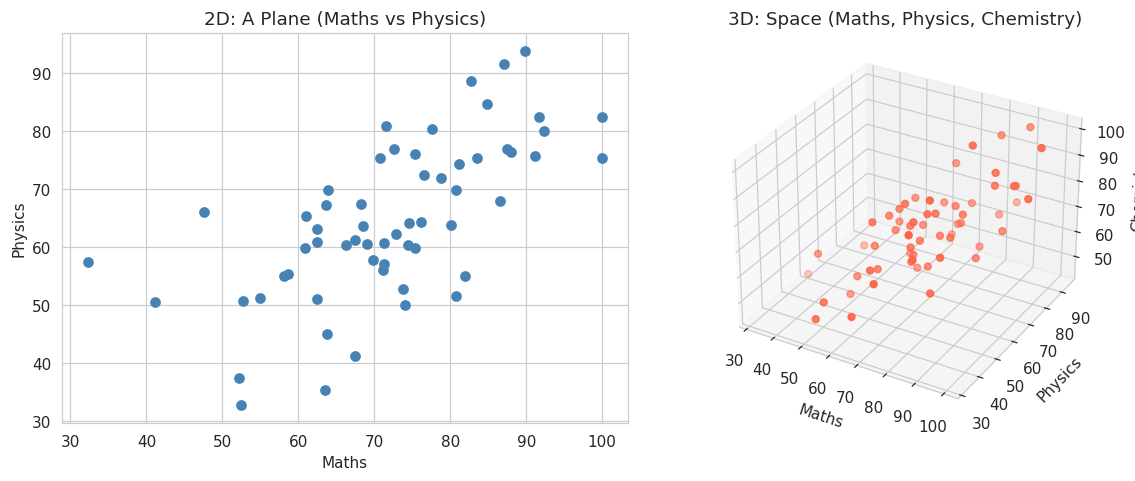

In [ ]:
fig = plt.figure(figsize=(11, 4.5))

ax1 = fig.add_subplot(1, 2, 1)
ax1.scatter(df['Maths'], df['Physics'], color='steelblue')
ax1.set_xlabel('Maths')
ax1.set_ylabel('Physics')
ax1.set_title('2D: A Plane (Maths vs Physics)')

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.scatter(df['Maths'], df['Physics'], df['Chemistry'], color='tomato')
ax2.set_xlabel('Maths')
ax2.set_ylabel('Physics')
ax2.set_zlabel('Chemistry')
ax2.set_title('3D: Space (Maths, Physics, Chemistry)')

plt.tight_layout()
plt.show()


* On the left, I plotted just two subjects against each other — every student becomes a single point in a flat 2D plane.
* On the right, I added a third subject as the z-axis, so now every student is a point floating in 3D space instead of sitting on a flat plane.
* With all 5 subjects, I'd need a 5D plot, which isn't something we can draw or see directly.
* This is exactly the problem PCA solves later — it finds the best possible 2D "plane" to project that 5D space onto, without losing much information.

## 🧮 Task 7 — Eigenvalues & Eigenvectors of the Covariance Matrix

In [ ]:
cov_matrix = np.cov(M, rowvar=False)
eigenvalues, eigenvectors = eig(cov_matrix)

order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order].real
eigenvectors = eigenvectors[:, order].real

for i, val in enumerate(eigenvalues):
    print(f"Eigenvalue {i+1}: {val:.2f}  (explains {val/eigenvalues.sum()*100:.1f}% of variance)")


Eigenvalue 1: 619.73  (explains 71.9% of variance)
Eigenvalue 2: 82.85  (explains 9.6% of variance)
Eigenvalue 3: 63.81  (explains 7.4% of variance)
Eigenvalue 4: 50.44  (explains 5.9% of variance)
Eigenvalue 5: 44.59  (explains 5.2% of variance)


* Here I calculated the covariance matrix of all 5 subjects, which measures how every pair of subjects varies together across all students.
* I then found its eigenvalues and eigenvectors — each eigenvector is a direction in the 5D score space, and its eigenvalue tells me how much variance the data has along that direction.
* I sorted them from largest to largest eigenvalue, since the biggest ones capture the most meaningful spread in student performance.
* This is the mathematical engine behind PCA — the top eigenvectors are exactly the directions PCA will use to compress the data later.

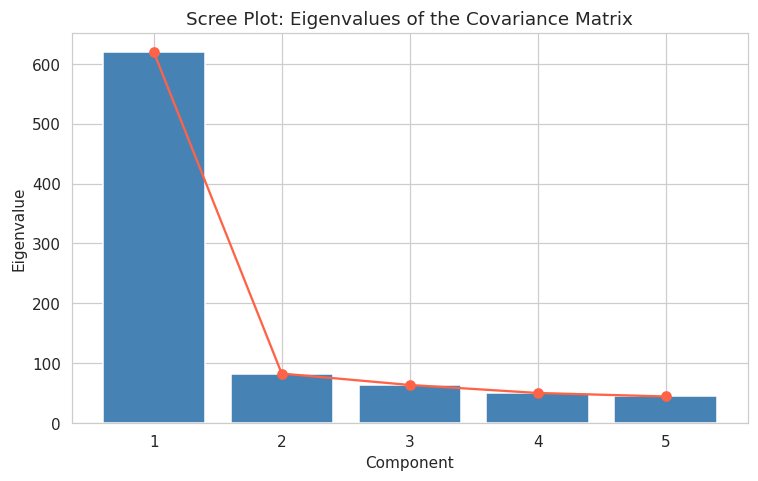

In [ ]:
plt.figure(figsize=(7, 4.5))
plt.bar(range(1, len(eigenvalues)+1), eigenvalues, color='steelblue')
plt.plot(range(1, len(eigenvalues)+1), eigenvalues, color='tomato', marker='o')
plt.xlabel('Component')
plt.ylabel('Eigenvalue')
plt.title('Scree Plot: Eigenvalues of the Covariance Matrix')
plt.tight_layout()
plt.show()


**Interpretation:** This scree plot shows how much variance each eigenvector direction captures. A steep drop after the first one or two components means most of the meaningful spread in student performance can be captured with just a couple of dimensions — which is the justification for reducing this 5-subject dataset down to 2D with PCA.

## 🧮 Task 8 — LU Decomposition

In [ ]:
M_square5 = M[:5, :5]   # 5x5 square matrix for a clean LU decomposition
P, L, U = lu(M_square5)

print("P (permutation matrix):\n", np.round(P, 2))
print("\nL (lower triangular):\n", np.round(L, 2))
print("\nU (upper triangular):\n", np.round(U, 2))


P (permutation matrix):
 [[0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0.]]

L (lower triangular):
 [[ 1.    0.    0.    0.    0.  ]
 [ 0.92  1.    0.    0.    0.  ]
 [ 0.94  0.16  1.    0.    0.  ]
 [ 0.88  0.92 -0.78  1.    0.  ]
 [ 0.86  0.04  0.52  0.22  1.  ]]

U (upper triangular):
 [[ 82.7   88.7   96.5   87.5   87.  ]
 [  0.   -17.22 -18.9    5.38  -0.86]
 [  0.     0.   -13.94 -17.99  -6.49]
 [  0.     0.     0.   -18.02  10.44]
 [  0.     0.     0.     0.    -0.7 ]]


* In this cell, I took a 5x5 square subset of the student-subject matrix and broke it apart using LU decomposition.
* `P` is a permutation matrix that reorders rows if needed to make the decomposition numerically stable.
* `L` is lower triangular and `U` is upper triangular — multiplying `P`, `L`, and `U` back together reconstructs the original matrix exactly.
* This kind of decomposition is what solvers use internally to efficiently solve systems of linear equations, rather than computing a full matrix inverse.

## 🧮 Task 9 — Singular Value Decomposition (SVD)

In [ ]:
U_svd, S, Vt = svd(M, full_matrices=False)

print("Singular values:", np.round(S, 2))
print("Shape of U:", U_svd.shape, " Shape of S:", S.shape, " Shape of Vt:", Vt.shape)


Singular values: [1230.69   69.93   61.79   54.96   51.89]
Shape of U: (60, 5)  Shape of S: (5,)  Shape of Vt: (5, 5)


* Here I applied Singular Value Decomposition to the full students x subjects matrix, breaking it into three pieces: `U`, `S`, and `Vt`.
* The singular values in `S` are ranked by importance — the largest ones capture the strongest patterns in the data, similar to what the eigenvalues did earlier.
* Unlike eigen-decomposition, SVD works on any matrix, even non-square ones, which is why it's the standard tool behind dimensionality reduction and recommendation systems.
* Keeping only the top few singular values and reconstructing the matrix gives a compressed, lower-rank approximation of the original data.

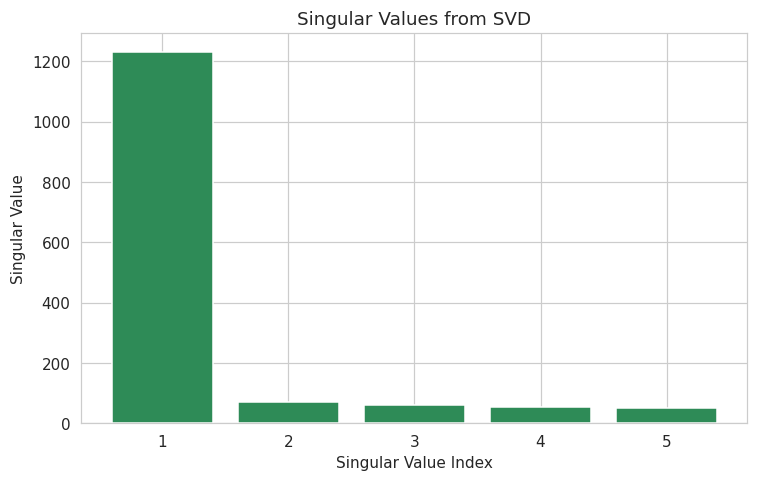

In [ ]:
plt.figure(figsize=(7, 4.5))
plt.bar(range(1, len(S)+1), S, color='seagreen')
plt.xlabel('Singular Value Index')
plt.ylabel('Singular Value')
plt.title('Singular Values from SVD')
plt.tight_layout()
plt.show()


**Interpretation:** Just like the scree plot earlier, this shows the singular values dropping off after the first couple of components. That drop-off is direct evidence that a handful of underlying patterns (like "overall academic strength") explain most of the differences between students, rather than each subject contributing independent, unrelated information.

## 🧮 Task 10 — Principal Component Analysis (PCA)

In [ ]:
pca = PCA(n_components=2)
pca_scores = pca.fit_transform(M)

print("Explained variance ratio:", np.round(pca.explained_variance_ratio_, 3))
print("Total variance captured by 2 components:", round(pca.explained_variance_ratio_.sum()*100, 1), "%")


Explained variance ratio: [0.719 0.096]
Total variance captured by 2 components: 81.6 %


* Here I used scikit-learn's PCA to reduce all 5 subject scores down to just 2 new dimensions, called principal components.
* Each principal component is a combination of the original subjects, built along the top eigenvector directions found earlier.
* The explained variance ratio tells me what percentage of the original spread in the data survives the compression down to 2D.
* This lets me visualize all 60 students on a simple 2D scatter plot instead of an unvisualizable 5D space.

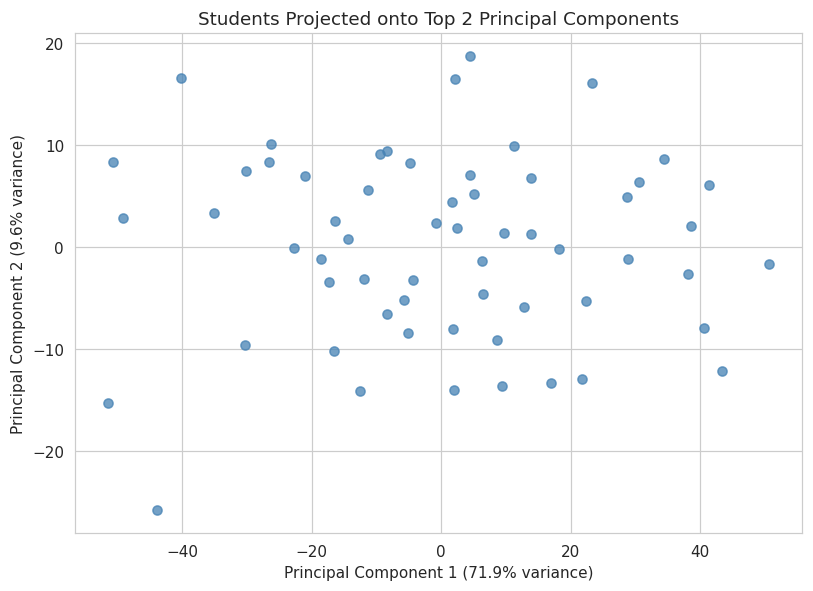

In [ ]:
plt.figure(figsize=(7.5, 5.5))
plt.scatter(pca_scores[:, 0], pca_scores[:, 1], color='steelblue', alpha=0.75)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('Students Projected onto Top 2 Principal Components')
plt.tight_layout()
plt.show()


**Interpretation:** Each dot is one student, now positioned using only their two most important "combined ability" scores instead of five separate subjects. Students clustered close together have a similar overall academic profile, while students far apart differ substantially — all while retaining most of the original variance.

## 🧮 Task 11 — Linear Discriminant Analysis (LDA)

In [ ]:
avg_score = M.mean(axis=1)
labels = np.where(avg_score >= avg_score.mean(), 'Above Average', 'Below Average')

lda = LinearDiscriminantAnalysis(n_components=1)
lda_scores = lda.fit_transform(M, labels)

print("Class counts:", pd.Series(labels).value_counts().to_dict())
print("LDA training accuracy:", round(lda.score(M, labels)*100, 1), "%")


Class counts: {'Above Average': 32, 'Below Average': 28}
LDA training accuracy: 95.0 %


* First, I labeled every student as "Above Average" or "Below Average" based on their mean score across all subjects, giving LDA something to classify.
* Unlike PCA, which only looks for spread, LDA specifically looks for the direction that best separates these two known groups.
* I reduced the data to a single LDA dimension, since separating just two classes only requires one discriminant axis.
* The training accuracy tells me how well that single combined score can correctly sort students back into their original above/below average groups.

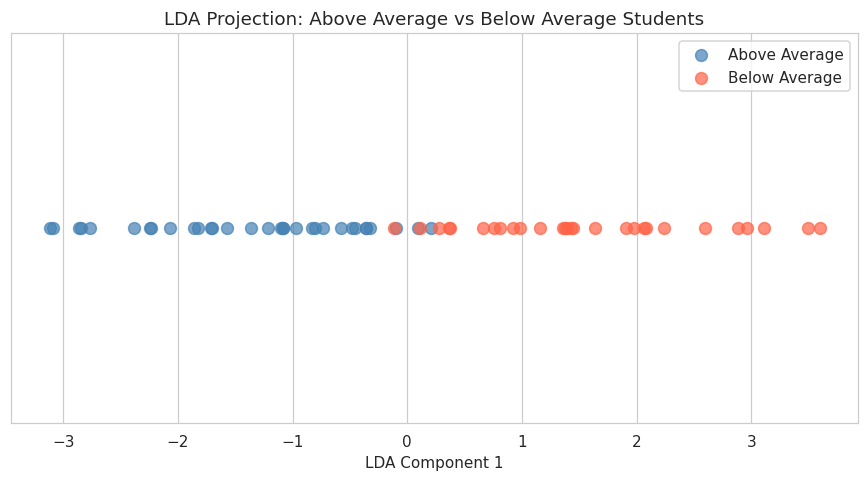

In [ ]:
plt.figure(figsize=(8, 4.5))
for label, color in zip(['Above Average', 'Below Average'], ['steelblue', 'tomato']):
    mask = labels == label
    plt.scatter(lda_scores[mask], np.zeros(mask.sum()), label=label, color=color, alpha=0.7, s=60)

plt.yticks([])
plt.xlabel('LDA Component 1')
plt.title('LDA Projection: Above Average vs Below Average Students')
plt.legend()
plt.tight_layout()
plt.show()


**Interpretation:** Each point is a student placed along the single axis LDA found to best separate the two groups. Clean separation between the blue and red clusters means overall subject performance is a strong, consistent signal — a student's five subject scores reliably predict which group they truly belong to.

## 📋 Task 12 — Summary of All Results & Conclusion

In [ ]:
summary = pd.DataFrame([
    {"Task": "Norms & Dot Product", "Method": "L1/L2 Norm, Dot Product", "Key Result": f"Angle between two students: {angle_deg:.1f} deg", "Conclusion": "Quantifies similarity of performance patterns"},
    {"Task": "Vector Projection", "Method": "Projection formula", "Key Result": f"Projection scalar: {proj_scalar:.2f}", "Conclusion": "Shows shared direction between two students' profiles"},
    {"Task": "Matrix Operations", "Method": "Add, Multiply, Transpose, Determinant", "Key Result": f"Det(4x4 subset) = {det_val:.2f}", "Conclusion": "Matrix subset is invertible (non-zero determinant)"},
    {"Task": "Eigen-decomposition", "Method": "Covariance matrix eigenvalues", "Key Result": f"Top eigenvalue explains {eigenvalues[0]/eigenvalues.sum()*100:.1f}% variance", "Conclusion": "One dominant direction drives most score variation"},
    {"Task": "LU Decomposition", "Method": "scipy.linalg.lu", "Key Result": "P, L, U reconstruct original matrix", "Conclusion": "Confirms matrix can be solved via triangular factors"},
    {"Task": "SVD", "Method": "numpy.linalg.svd", "Key Result": f"Top singular value: {S[0]:.2f}", "Conclusion": "Confirms low-rank structure suitable for compression"},
    {"Task": "PCA", "Method": "sklearn PCA (2 components)", "Key Result": f"{pca.explained_variance_ratio_.sum()*100:.1f}% variance retained in 2D", "Conclusion": "5 subjects compress well into 2 dimensions"},
    {"Task": "LDA", "Method": "sklearn LDA (1 component)", "Key Result": f"{lda.score(M, labels)*100:.1f}% classification accuracy", "Conclusion": "Overall performance strongly separates the two groups"},
])
summary


,Task,Method,Key Result,Conclusion
0,Norms & Dot Product,"L1/L2 Norm, Dot Product",Angle between two students: 9.3 deg,Quantifies similarity of performance patterns
1,Vector Projection,Projection formula,Projection scalar: 1.05,Shows shared direction between two students' p...
2,Matrix Operations,"Add, Multiply, Transpose, Determinant",Det(4x4 subset) = 247147.68,Matrix subset is invertible (non-zero determin...
3,Eigen-decomposition,Covariance matrix eigenvalues,Top eigenvalue explains 71.9% variance,One dominant direction drives most score varia...
4,LU Decomposition,scipy.linalg.lu,"P, L, U reconstruct original matrix",Confirms matrix can be solved via triangular f...
5,SVD,numpy.linalg.svd,Top singular value: 1230.69,Confirms low-rank structure suitable for compr...
6,PCA,sklearn PCA (2 components),81.6% variance retained in 2D,5 subjects compress well into 2 dimensions
7,LDA,sklearn LDA (1 component),95.0% classification accuracy,Overall performance strongly separates the two...


* This final cell doesn't calculate anything new — it just gathers every key number from Tasks 1 through 11 into one table.
* Each row shows the method used, the key numeric result, and a one-line conclusion in plain English.
* Having everything in one place makes it easy to compare, say, how much variance PCA kept versus how accurate LDA's classification was.
* Overall, the results confirm that student performance across 5 subjects is driven by a small number of underlying patterns, which linear algebra tools like PCA and SVD are able to isolate and quantify.